# 6. Rheology and Io

The fixed-Q model of the previous notebook hid all the interior physics inside two constants. A real
body's tidal response depends on how its material deforms under a periodic load, which is set by its
**rheology**. The rheology combines an elastic shear modulus and a viscosity into a *complex* shear
modulus that depends on the forcing frequency, and the radial solver turns that into a complex Love
number `k2`. The imaginary part of `k2` sets the dissipation, so `-Im(k2)` (times orbital factors) is
the tidal heating.

Dissipation peaks when the material's Maxwell time (viscosity over shear modulus) is comparable to the
tidal period. This notebook maps Io's tidal heating across shear modulus and viscosity for four
rheologies, and shows how to swap rheologies without rebuilding the planet.


In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from TidalPy.constants import G
from TidalPy.RadialSolver_x import radial_solver
from TidalPy.rheology_x import Maxwell, Burgers, Andrade, Sundberg

# Io as a homogeneous sphere raised by Jupiter's tide.
R = 1.8216e6
M = 8.9319e22
RHO = M / (4.0 / 3.0 * np.pi * R**3)
M_JUP = 1.898e27
A_IO = 4.217e8
E_IO = 0.0041
N_MOTION = np.sqrt(G * M_JUP / A_IO**3)

# A fixed radial grid; only the complex shear modulus changes as we vary the rheology.
SLICES = 60
_radius = np.linspace(0.0, R, SLICES)
_density = np.full(SLICES, RHO)
_bulk = np.full(SLICES, 200.0e9 + 0j)

def love_k2(shear_pa, viscosity_pas, rheology):
    "Complex tidal k2 for a homogeneous Io with the given shear modulus, viscosity, and rheology."
    complex_shear = rheology.calc_complex_modulus(shear_pa, viscosity_pas, N_MOTION)
    solution = radial_solver(
        _radius, _density, _bulk, np.full(SLICES, complex_shear, dtype=np.complex128),
        N_MOTION, RHO, ("solid",), (True,), (False,), np.array([R]),
        degree_l=2, solve_for=("tidal",))
    return complex(np.atleast_1d(solution.k)[0])

def heating(shear_pa, viscosity_pas, rheology, ecc=E_IO):
    "Tidal heating [W] from the leading e^2 term: (21/2) (-Im k2) G M_host^2 R^5 e^2 n / a^6."
    neg_im_k2 = -love_k2(shear_pa, viscosity_pas, rheology).imag
    return 10.5 * neg_im_k2 * G * M_JUP**2 * R**5 * ecc**2 * N_MOTION / A_IO**6

# Swapping the rheology is just passing a different object; the planet is never rebuilt.
for name, rheo in [("Maxwell", Maxwell()), ("Andrade", Andrade(0.3, 1.0))]:
    print(f"{name:8}  k2 = {love_k2(60e9, 1e14, rheo):.4f}   heating = {heating(60e9, 1e14, rheo):.3e} W")


Maxwell   k2 = 0.1437-0.3932j   heating = 2.446e+15 W
Andrade   k2 = 0.1955-0.3880j   heating = 2.414e+15 W


## Heating across shear modulus and viscosity

For each of four rheologies we sweep the mantle shear modulus and viscosity and map the tidal heating. The diagonal ridge in each panel is where the Maxwell time meets the tidal period; the transient terms in Andrade, Burgers, and Sundberg-Cooper broaden that ridge toward higher viscosity, which is why they dissipate over a wider range of conditions than a plain Maxwell body.

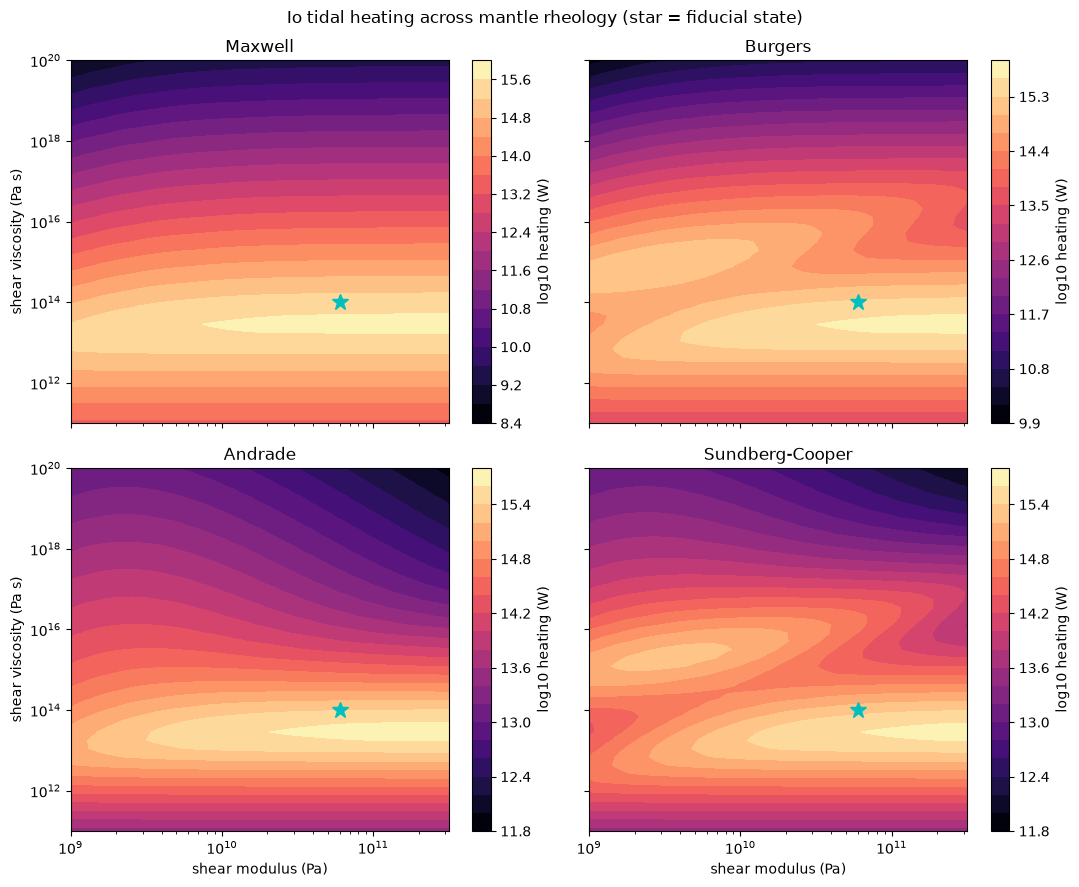

In [2]:
shear_axis = np.logspace(9.0, 11.5, 45)     # 1 GPa to ~300 GPa
visc_axis = np.logspace(11.0, 20.0, 45)     # 1e11 to 1e20 Pa s
SH, VI = np.meshgrid(shear_axis, visc_axis)

rheologies = [
    ("Maxwell", Maxwell()),
    ("Burgers", Burgers(0.3, 0.05)),
    ("Andrade", Andrade(0.3, 1.0)),
    ("Sundberg-Cooper", Sundberg(0.3, 1.0, 0.2, 0.02)),
]

fig, axes = plt.subplots(2, 2, figsize=(11, 9), sharex=True, sharey=True)
for ax, (name, rheo) in zip(axes.ravel(), rheologies):
    grid = np.array([[heating(mu, eta, rheo) for mu in shear_axis] for eta in visc_axis])
    cf = ax.contourf(SH, VI, np.log10(grid), levels=20, cmap="magma")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_title(name)
    ax.plot(60e9, 1e14, "c*", ms=12)      # a fiducial mantle state
    fig.colorbar(cf, ax=ax, label="log10 heating (W)")
for ax in axes[-1]:
    ax.set_xlabel("shear modulus (Pa)")
for ax in axes[:, 0]:
    ax.set_ylabel("shear viscosity (Pa s)")
fig.suptitle("Io tidal heating across mantle rheology (star = fiducial state)")
fig.tight_layout()
plt.show()


## Heating versus eccentricity across rheologies

At a fixed mantle state, all four rheologies still grow as roughly `e^2`, but they differ in absolute level because each converts the same forcing into a different amount of dissipation. The eccentricity range is the one Io is thought to have occupied (Hussmann & Spohn 2004).

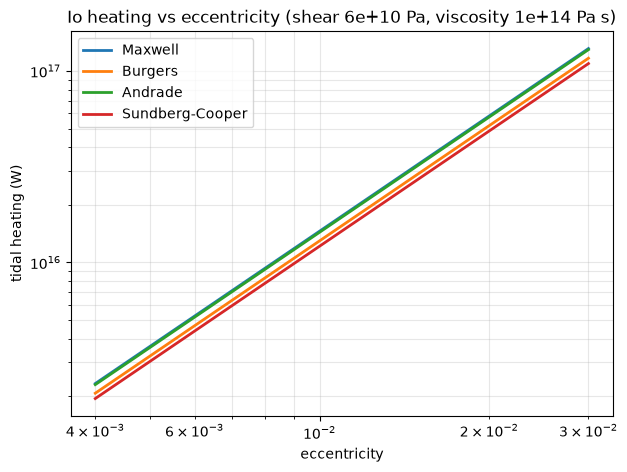

In [3]:
eccs = np.linspace(0.004, 0.03, 60)
mu0, eta0 = 60.0e9, 1.0e14

fig, ax = plt.subplots(figsize=(7, 5))
for name, rheo in rheologies:
    curve = [heating(mu0, eta0, rheo, ecc=e) for e in eccs]
    ax.loglog(eccs, curve, lw=2, label=name)
ax.set_xlabel("eccentricity")
ax.set_ylabel("tidal heating (W)")
ax.set_title(f"Io heating vs eccentricity (shear {mu0:.0e} Pa, viscosity {eta0:.0e} Pa s)")
ax.legend()
ax.grid(alpha=0.3, which="both")
plt.show()


## Recap

- A rheology maps a shear modulus and a viscosity to a frequency-dependent complex shear modulus; the
  radial solver turns that into a complex Love number `k2`, and `-Im(k2)` drives the heating.
- Swapping the rheology is just handing a different rheology object to the solver; no planet is rebuilt.
  That makes broad sweeps over material state and rheology cheap.
- Dissipation peaks where the Maxwell time meets the tidal period; Andrade, Burgers, and Sundberg-Cooper
  broaden that peak because of their transient response.

Next: **`07_gasgiant_fixedQ_dt`** applies the analytic fixed-Q and fixed-dt models to a short-period
gas giant; after that, **`08_love_numbers_1d`** looks at the Love numbers themselves for layered
interiors.
